In [3]:
import zipfile
with zipfile.ZipFile('/content/archive (2).zip','r') as z:
  z.extractall('/content/')
  print(z.namelist())

['spam.csv']


In [4]:
import pandas as pd

df = pd.read_csv('/content/spam.csv', encoding='latin-1')

# Drop the unnamed leftover columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Keep only the two relevant columns and rename them
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.columns)
df.head()

Index(['label', 'message'], dtype='object')


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


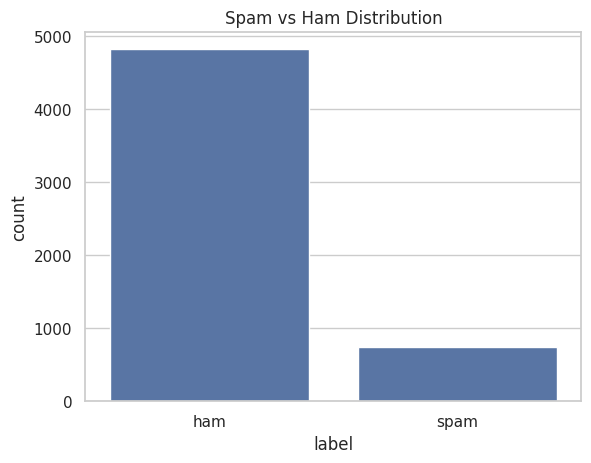

In [5]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()


In [6]:
import nltk
from nltk.corpus import stopwords
import re
import string

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [7]:
# Encode labels: ham -> 0, spam -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_message']).toarray()
y = df['label_num']

print(X.shape)
print(y.value_counts())

(5572, 3000)
label_num
0    4825
1     747
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(4457, 3000) (1115, 3000)
label_num
0    3859
1     598
Name: count, dtype: int64
label_num
0    966
1    149
Name: count, dtype: int64


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

print("Naive Bayes trained.")


Naive Bayes trained.


In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Logistic Regression trained.")

Logistic Regression trained.


--- Multinomial Naive Bayes ---
Accuracy:  0.9713004484304932
Precision: 0.9915966386554622
Recall:  0.7919463087248322
F1 Score:  0.8805970149253731

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



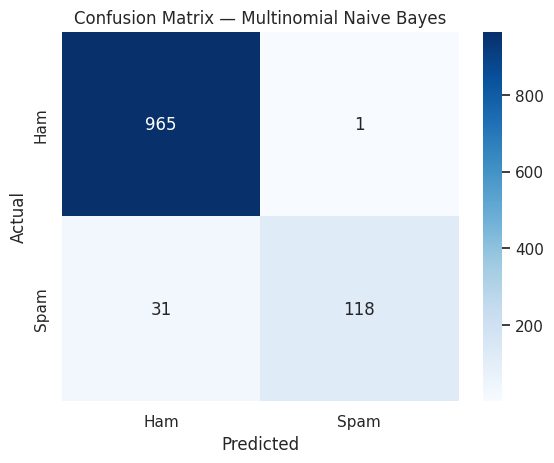

--- Logistic Regression ---
Accuracy:  0.9632286995515695
Precision: 0.990909090909091
Recall:  0.7315436241610739
F1 Score:  0.8416988416988417

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



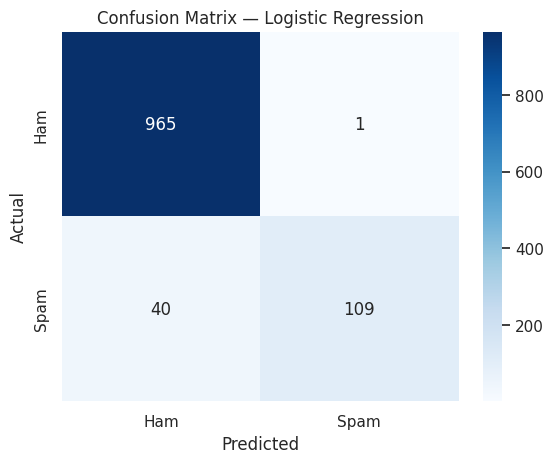

In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy: ", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall: ", recall_score(y_true, y_pred))
    print("F1 Score: ", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

evaluate_model("Multinomial Naive Bayes", y_test, nb_preds)
evaluate_model("Logistic Regression", y_test, lr_preds)





Comparing the two models on the test set:

- **Multinomial Naive Bayes** achieved an accuracy of 97.1%, precision of 0.992,
  recall of 0.792, and F1-score of 0.881.
- **Logistic Regression** achieved an accuracy of 96.3%, precision of 0.991,
  recall of 0.732, and F1-score of 0.842.

Multinomial Naive Bayes outperformed Logistic Regression across every metric,
particularly recall — it correctly identified 118 out of 149 spam messages,
compared to 109 out of 149 for Logistic Regression. Since missing actual spam
is generally the costlier error in a spam filter, and Naive Bayes also achieved
higher precision (fewer ham messages wrongly flagged as spam, with only 1
false positive), Naive Bayes is the stronger model for this task. This result
also aligns with expectations, since Naive Bayes is the traditional industry
baseline for text classification problems like this one.



### Why Recall Matters for Spam Detection

Recall measures how many actual spam messages the model successfully catches.
Both models here have very high precision (>99%) — almost no ham messages are
wrongly flagged as spam — but recall is noticeably lower (73–79%), meaning a
meaningful chunk of spam still slips through as false negatives. In a real
spam filter, missing spam is usually more costly than the rare false positive,
especially if it includes phishing attempts. This is why recall — and F1,
which balances recall with precision — matters more than raw accuracy when
judging which model to deploy.

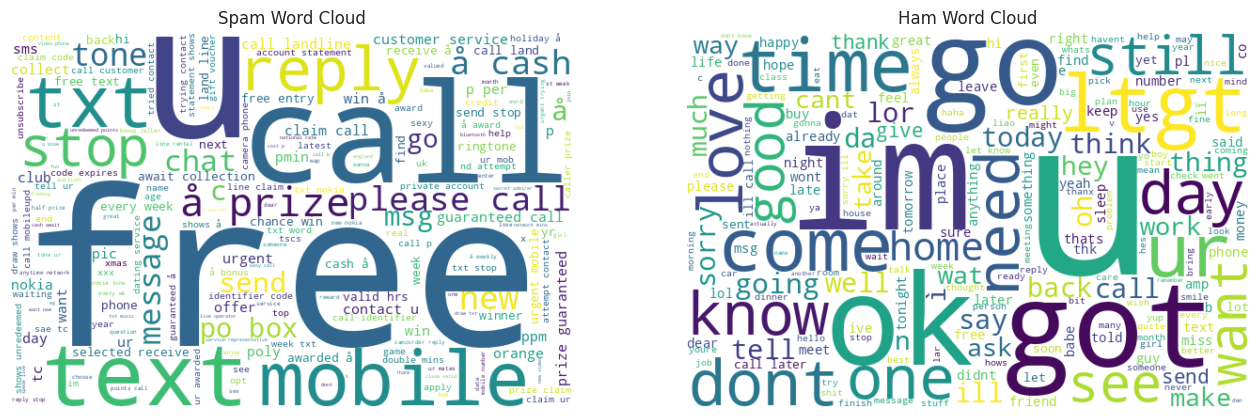

In [13]:
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_words = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_words = ' '.join(df[df['label'] == 'ham']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

spam_wc = WordCloud(width=600, height=400, background_color='white').generate(spam_words)
axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].set_title("Spam Word Cloud")
axes[0].axis('off')

ham_wc = WordCloud(width=600, height=400, background_color='white').generate(ham_words)
axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].set_title("Ham Word Cloud")
axes[1].axis('off')

plt.show()

##Conclusion
In this project, it was possible to analyze SMS messages for determining whether they were spam or ham through text preprocessing and visualization. From the generated word clouds, differences were clearly visible in the type of words used in both categories of SMS messages. In case of spam SMS messages, there were words related to advertisements, offers, and prizes. Words such as "free," "call," "txt," "text," "mobile," and "reply" were used in those SMS messages.
Conversely, the ham SMS messages contained words such as "u," "go," "ok," "come," "love," and "know." This shows that the SMS messages were part of daily conversations. It is evident that text-based characteristics provide useful information on the identification of spam messages.